## **Practical Tasks**
**Task 1: House Price Prediction**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/Mumbai.csv')
df.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,4850000,720,Kharghar,1,1,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1,4500000,600,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
2,6700000,650,Kharghar,1,1,1,1,1,0,1,...,1,0,1,0,0,0,0,0,0,0
3,4500000,650,Kharghar,1,1,1,0,0,1,0,...,1,1,1,0,0,0,0,0,1,0
4,5000000,665,Kharghar,1,1,1,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0


In [ ]:
df.shape

(7719, 41)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7719 entries, 0 to 7718
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                7719 non-null   int64 
 1   Area                 7719 non-null   int64 
 2   Location             7719 non-null   object
 3   No. of Bedrooms      7719 non-null   int64 
 4   Resale               7719 non-null   int64 
 5   MaintenanceStaff     7719 non-null   int64 
 6   Gymnasium            7719 non-null   int64 
 7   SwimmingPool         7719 non-null   int64 
 8   LandscapedGardens    7719 non-null   int64 
 9   JoggingTrack         7719 non-null   int64 
 10  RainWaterHarvesting  7719 non-null   int64 
 11  IndoorGames          7719 non-null   int64 
 12  ShoppingMall         7719 non-null   int64 
 13  Intercom             7719 non-null   int64 
 14  SportsFacility       7719 non-null   int64 
 15  ATM                  7719 non-null   int64 
 16  ClubHo

In [ ]:
df.describe()

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium,Location_label
count,7.719000e+03,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,...,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000,7719.000000
mean,1.506165e+07,998.409250,1.913331,0.647105,7.498899,7.473896,7.437881,7.441638,7.439435,7.477005,...,7.417930,7.454722,7.372069,7.379712,7.379065,7.373624,7.374530,7.383988,7.374789,183.829900
std,2.052100e+07,550.967809,0.855376,0.477901,3.197923,3.252095,3.328245,3.320401,3.325002,3.245418,...,3.369523,3.292904,3.462108,3.446892,3.448185,3.459020,3.457217,3.438345,3.456702,113.135716
min,2.000000e+06,200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.300000e+06,650.000000,1.000000,0.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,108.000000
50%,9.500000e+06,900.000000,2.000000,1.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,170.000000
75%,1.700000e+07,1177.000000,2.000000,1.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,277.000000
max,4.200000e+08,8511.000000,7.000000,1.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,412.000000


In [ ]:
#Missing values
df.isnull().sum()

,0
Price,0
Area,0
Location,0
No. of Bedrooms,0
Resale,0
MaintenanceStaff,0
Gymnasium,0
SwimmingPool,0
LandscapedGardens,0
JoggingTrack,0


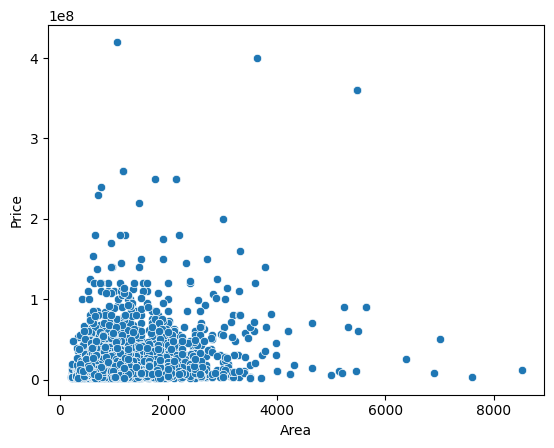

In [ ]:
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.show()

In [ ]:
df.head()


,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium,Location_label
0,4850000,720,Kharghar,1,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,136
1,4500000,600,Kharghar,1,1,1,1,1,0,1,...,0,1,0,0,0,0,0,0,0,136
2,6700000,650,Kharghar,1,1,1,1,1,0,1,...,0,1,0,0,0,0,0,0,0,136
3,4500000,650,Kharghar,1,1,1,0,0,1,0,...,1,1,0,0,0,0,0,1,0,136
4,5000000,665,Kharghar,1,1,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,136


In [ ]:
#Label Encoding
lcoder= LabelEncoder()
df['Location_label'] = lcoder.fit_transform(df['Location'])

In [ ]:
x = df.drop(['Location','Price'],axis=1)
y = df['Price']

In [ ]:
scaler_s = StandardScaler()
x_scaled_s = scaler_s.fit_transform(x)
x_scaled_s

array([[-0.5053422 , -1.06782233,  0.73847501, ..., -2.14768038,
        -2.13361404, -0.42279309],
       [-0.72315488, -1.06782233,  0.73847501, ..., -2.14768038,
        -2.13361404, -0.42279309],
       [-0.6323996 , -1.06782233,  0.73847501, ..., -2.14768038,
        -2.13361404, -0.42279309],
       ...,
       [-0.54164432, -1.06782233, -1.35414196, ...,  0.47002763,
         0.47019267,  1.20367754],
       [-0.00618815,  0.10132952, -1.35414196, ...,  0.47002763,
         0.47019267, -0.04269397],
       [ 0.03918949,  0.10132952, -1.35414196, ...,  0.47002763,
         0.47019267, -0.04269397]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled_s, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6175, 39)
(1544, 39)
(6175,)
(1544,)


In [ ]:
#2. Build a Simple Linear Regression model to predict the Sale price of the house.Use Area as the independent variable
X = df[['Area']]
Y = df['Price']
X_train_slr, X_test_slr,Y_train_slr,Y_test_slr = train_test_split(X,Y, test_size=0.2, random_state=42)
slr = LinearRegression()
slr.fit(X_train_slr,Y_train_slr)
slr_pred = slr.predict(X_test_slr)

mse = mean_squared_error(Y_test_slr, slr_pred)
rmse = np.sqrt(mse)

print("SLR RMSE:", rmse)
print("SLR R2:", r2_score(Y_test_slr, slr_pred))


SLR RMSE: 21126875.108592935
SLR R2: 0.07350597833814321


In [ ]:
#3. Build Multiple Linear Regression model to predict Sale price of the house.
mlr = LinearRegression()
mlr.fit(X_train, y_train)
mlr_pred = mlr.predict(X_test)

print("MLR RMSE:", np.sqrt(mean_squared_error(y_test, mlr_pred)))
print("MLR R2:", r2_score(y_test, mlr_pred))


MLR RMSE: 21119848.311029658
MLR R2: 0.07412217957376999


In [ ]:
#4. Use dimensionality reduction technique PCA/LDA and build Multiple Linear Regression model to predict Sale price of the house

pca = PCA(n_components=10)
X_pca = pca.fit_transform(x_scaled_s)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

pca_lr = LinearRegression()
pca_lr.fit(X_train_pca, y_train_pca)

pca_pred = pca_lr.predict(X_test_pca)

print("PCA RMSE:", np.sqrt(mean_squared_error(y_test_pca, pca_pred)))
print("PCA R2:", r2_score(y_test_pca, pca_pred))


PCA RMSE: 20965070.240253124
PCA R2: 0.08764315462555816


In [ ]:
#5. Build a model using Lasso and Ridge regression to reduce model complexity.
ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
mse_ridge = mean_squared_error(y_test,ridge_pred)
mse_lasso = mean_squared_error(y_test,lasso_pred )

print('Ridge Mse ',mse_ridge)
print("Ridge R2:", r2_score(y_test, ridge_pred))
print('Lasso Mse',mse_lasso)
print("Lasso R2:", r2_score(y_test, lasso_pred))

Ridge Mse  443440570682204.9
Ridge R2: 0.07953449895800369
Lasso Mse 444187910711001.94
Lasso R2: 0.07798321844932776


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.100e+18, tolerance: 2.505e+14
  model = cd_fast.enet_coordinate_descent(


In [ ]:
#6. Build an SVR model to predict Sale price of the house.

# Scale y (Price)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).ravel()

# Train-test split
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(
    x_scaled_s, y_scaled, test_size=0.2, random_state=42
)

svr = SVR(kernel='rbf')
svr.fit(X_train_svr, y_train_svr)

# Predictions (scaled)
y_pred_scaled = svr.predict(X_test_svr)

# Inverse transform to original price
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))
y_test_original = scaler_y.inverse_transform(y_test_svr.reshape(-1,1))

print("SVR R2:", r2_score(y_test_original, y_pred))
rmse = mean_squared_error(y_test_original, y_pred) ** 0.5
print("SVR RMSE:", rmse)


SVR R2: 0.05280518021389058
SVR RMSE: 21361591.78020327


In [ ]:
#7. Find optimal parameters for the algorithm through GridSearchCV and build a Decision tree which will predict whether a customer is at risk to churn from the platform

dt = DecisionTreeRegressor(max_depth=10)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("DT R2:", r2_score(y_test, dt_pred))


DT R2: -0.15857988636557363


In [ ]:
#8. Build Random Forest Regression model to predict Sale price of the house
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))


RF R2: -0.024878720911403862


In [ ]:
#9. Use GridsearchCV and RandomizedsearchCV for tuning hyperparameters and fit your model on the optimal parameters.

#GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_grid_model = grid.best_estimator_
grid_pred = best_grid_model.predict(X_test)

print("GridSearch Best Params:", grid.best_params_)
print("GridSearch R2 Score:", r2_score(y_test, grid_pred))
print("GridSearch RMSE:", mean_squared_error(y_test, grid_pred) ** 0.5)

GridSearch Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
GridSearch R2 Score: 0.039183848368062546
GridSearch RMSE: 21514640.909397162


In [ ]:
 #RandomizedsearchCV
param_dist = {
    "n_estimators": np.arange(50, 301, 50),
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": np.arange(2, 11),
}

rand = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rand.fit(X_train, y_train)

best_rand_model = rand.best_estimator_
rand_pred = best_rand_model.predict(X_test)

print("RandomizedSearch Best Params:", rand.best_params_)
print("RandomSearch R2:", r2_score(y_test, rand_pred))


In [ ]:
#10.Model Selection: Evaluate and compare performance of all the models to find the best model.
results = {
    "Simple LR": r2_score(Y_test_slr, slr_pred),
    "Multiple LR": r2_score(y_test, mlr_pred),
    "PCA + LR": r2_score(y_test, pca_pred),
    "Lasso": r2_score(y_test, lasso_pred),
    "Ridge": r2_score(y_test, ridge_pred),
    "SVR": r2_score(y_test_original, y_pred),
    "Decision Tree": r2_score(y_test, dt_pred),
    "Random Forest": r2_score(y_test, rf_pred),
    # "GridSearch RF": r2_score(y_test, grid_pred),
    # "RandomSearch RF": r2_score(y_test, rand_pred),
}

results_df = pd.DataFrame(results, index=["R2 Score"]).T
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)



               R2 Score
PCA + LR       0.087643
Ridge          0.079534
Lasso          0.077983
Multiple LR    0.074122
Simple LR      0.073506
SVR            0.052805
Random Forest -0.024879
Decision Tree -0.158580
